<a href="https://colab.research.google.com/github/vivek-bhushan/vivek-bhushan-IITM-WEEK29/blob/main/Week_29_Graded_Mini_Project_%5BVivek-Bhushan%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week_29_Graded_Mini_Project_[Vivek-Bhushan]
#[ADVANCED LLMs SPECIALISATION]

# My Reliable Retail Assistant (Text RAG + Multimodal RAG)

## Goal
I built a retail assistant that successfully supported:
- **Text RAG**: text query → retrieved products → recommended (grounded)
- **Multimodal RAG**: image → extracted query → retrieved products → recommended

## Engineering Qualities I Implemented
- I designed a structured output schema (JSON) and enforced validation.
- I capped the execution loop with budgeted agent steps.
- I structured my own observability logs.
- I evaluated my agent using a lightweight evaluation harness.

In [1]:
!pip install --upgrade openai faiss-cpu pydantic pillow 'pandas==2.2.3' 'numpy<2.3'

### Note on Imports
After my pip installations completed, I executed the code cell below to import `faiss`, `openai`, and other libraries required for my pipeline.

## Setup: Vocareum OpenAI Gateway

I set my API key as an environment variable before continuing.

In [2]:
import os
os.environ["OPENAI_API_KEY"] = "voc-137331098316514747226336abca35399f6c7.92368348"
print("API Key loaded into environment successfully.")

API Key loaded into environment successfully.


In [3]:
import os, json, time, base64, mimetypes
import numpy as np
import pandas as pd
import faiss

from typing import List, Dict, Any, Optional, Literal
from pydantic import BaseModel, Field, ValidationError
from PIL import Image

from openai import OpenAI

BASE_URL = "https://openai.vocareum.com/v1"
API_KEY = os.environ.get("OPENAI_API_KEY", "")
if not API_KEY:
    raise RuntimeError("Set OPENAI_API_KEY env var before running.")

client = OpenAI(api_key=API_KEY, base_url=BASE_URL)

TEXT_MODEL = "gpt-4o-mini"
EMBED_MODEL = "text-embedding-3-small"
VISION_MODEL = "gpt-4o-mini"

print("Libraries imported. Models configured:")
print(f"- Text Model: {TEXT_MODEL}")
print(f"- Embedding Model: {EMBED_MODEL}")
print(f"- Vision Model: {VISION_MODEL}")

Libraries imported. Models configured:
- Text Model: gpt-4o-mini
- Embedding Model: text-embedding-3-small
- Vision Model: gpt-4o-mini


#A: at least 20 products; required fields *and* doc preparation

### [TASK A]: Dataset Preparation and Document Conversion Guidelines
In this section, I prepared a high-quality retail product dataset consisting of 31 items spanning 5 core categories. I also built a structured document conversion mapping helper (`product_to_text`) that transformed my structured database rows into descriptive textual documents ready for my vector database.

## [TASK A] : Dataset Preparation & Document Conversion

## Step 1 — My Product Catalog

I expanded the dataset to include a minimum of 20 products spanning multiple categories like:
- laptops, phones, shoes, headphones, and earbuds.

In [4]:
import pandas as pd

# [TASK A]: Dataset preparation (at least 20 items with structured attributes)
products = [
    {"id":"S1","name":"Nike Air Zoom Pegasus","category":"shoes","price":95,"brand":"Nike","specs":"Use: Running, Cushioning: Medium, Weight: Light, Road running","desc":"Daily trainer for road running with balanced cushioning."},
    {"id":"S2","name":"Adidas Ultraboost Light","category":"shoes","price":110,"brand":"Adidas","specs":"Use: Running, Cushioning: High, Weight: Medium, Road running","desc":"Premium road-running shoe with responsive cushioning."},
    {"id":"S3","name":"Converse Chuck Taylor","category":"shoes","price":55,"brand":"Converse","specs":"Use: Casual, Cushioning: Low, Weight: Light","desc":"Classic casual sneaker, not designed for running."},
    {"id":"S4","name":"Brooks Ghost 15","category":"shoes","price":99,"brand":"Brooks","specs":"Use: Running, Cushioning: Medium, Weight: Light, Road running","desc":"Comfortable neutral running shoe for daily miles."},
    {"id":"S5","name":"Vans Old Skool","category":"shoes","price":70,"brand":"Vans","specs":"Use: Casual, Flat sole, Canvas upper","desc":"Casual lifestyle sneaker for everyday wear."},
    {"id":"S6","name":"ASICS Gel-Kayano 30","category":"shoes","price":145,"brand":"ASICS","specs":"Use: Running, Stability: High, Cushioning: High","desc":"Supportive stability running shoe for longer distances."},
    {"id":"P1","name":"iPhone 13","category":"phone","price":599,"brand":"Apple","specs":"Wireless charging: Yes, 4GB RAM, 128GB storage, 5G","desc":"Compact 5G smartphone with MagSafe wireless charging."},
    {"id":"P2","name":"Google Pixel 7a","category":"phone","price":499,"brand":"Google","specs":"Wireless charging: Yes, 8GB RAM, 128GB storage, 5G","desc":"Great camera and clean Android with wireless charging."},
    {"id":"P3","name":"Moto G Power","category":"phone","price":199,"brand":"Motorola","specs":"Wireless charging: No, 4GB RAM, 64GB storage, 4G","desc":"Budget phone with large battery and basic performance."},
    {"id":"P4","name":"Samsung Galaxy S23","category":"phone","price":799,"brand":"Samsung","specs":"Wireless charging: Yes, 8GB RAM, 256GB storage, 5G","desc":"Premium Android phone with fast performance and wireless charging."},
    {"id":"P5","name":"OnePlus Nord N30","category":"phone","price":299,"brand":"OnePlus","specs":"Wireless charging: No, 8GB RAM, 128GB storage, 5G","desc":"Affordable phone with fast wired charging."},
    {"id":"P6","name":"Nothing Phone 1","category":"phone","price":449,"brand":"Nothing","specs":"Wireless charging: Yes, 8GB RAM, 256GB storage, 5G","desc":"Distinctive midrange phone supporting wireless charging."},
    {"id":"L1","name":"Acer Nitro 5","category":"laptop","price":899,"brand":"Acer","specs":"i7, RTX 4060 dedicated GPU, 16GB RAM, 512GB SSD, 144Hz","desc":"Gaming laptop with dedicated GPU and high refresh display."},
    {"id":"L2","name":"Lenovo Legion 5","category":"laptop","price":999,"brand":"Lenovo","specs":"Ryzen 7, RTX 4060 dedicated GPU, 16GB RAM, 1TB SSD, 165Hz","desc":"Powerful gaming laptop with dedicated graphics under $1000."},
    {"id":"L3","name":"Dell Inspiron 15","category":"laptop","price":650,"brand":"Dell","specs":"i5, integrated graphics, 8GB RAM, 512GB SSD","desc":"Everyday productivity laptop without a dedicated GPU."},
    {"id":"L4","name":"ASUS ROG Zephyrus G14","category":"laptop","price":1299,"brand":"ASUS","specs":"Ryzen 9, RTX 4070 dedicated GPU, 16GB RAM, 1TB SSD","desc":"Premium compact gaming laptop with dedicated graphics."},
    {"id":"L5","name":"HP Pavilion 14","category":"laptop","price":720,"brand":"HP","specs":"i5, integrated graphics, 16GB RAM, 512GB SSD","desc":"Lightweight laptop for office and study work."},
    {"id":"H1","name":"Sony WH-1000XM5","category":"headphones","price":349,"brand":"Sony","specs":"Wireless, active noise cancellation, over-ear, 30-hour battery","desc":"Premium wireless over-ear headphones with strong noise cancellation."},
    {"id":"H2","name":"Anker Soundcore Q30","category":"headphones","price":79,"brand":"Anker","specs":"Wireless, active noise cancellation, over-ear, 40-hour battery","desc":"Affordable noise-cancelling wireless headphones."},
    {"id":"H3","name":"JBL Tune 510BT","category":"headphones","price":49,"brand":"JBL","specs":"Wireless, on-ear, 40-hour battery, no ANC","desc":"Simple lightweight wireless headphones for everyday listening."},
    {"id":"E1","name":"Apple AirPods Pro 2","category":"earbuds","price":249,"brand":"Apple","specs":"Wireless, active noise cancellation, in-ear, transparency mode","desc":"Compact premium earbuds with ANC and transparency mode."},
    {"id":"E2","name":"Samsung Galaxy Buds FE","category":"earbuds","price":99,"brand":"Samsung","specs":"Wireless, active noise cancellation, in-ear","desc":"Comfortable affordable earbuds with noise cancellation."},
    {"id":"E3","name":"Jabra Elite 4","category":"earbuds","price":79,"brand":"Jabra","specs":"Wireless, in-ear, multipoint Bluetooth, IP55","desc":"Durable everyday earbuds with multipoint connectivity."},
    {"id":"E4","name":"Sony WF-C700N","category":"earbuds","price":119,"brand":"Sony","specs":"Wireless, active noise cancellation, in-ear, lightweight","desc":"Lightweight noise-cancelling earbuds for commuting."},
    {"id":"S7","name":"New Balance Fresh Foam 1080","category":"shoes","price":130,"brand":"New Balance","specs":"Use: Running, Cushioning: High, Weight: Medium","desc":"Soft cushioned running shoe for comfortable daily training."},
    {"id":"H4","name":"Bose QuietComfort","category":"headphones","price":279,"brand":"Bose","specs":"Wireless, active noise cancellation, over-ear","desc":"Comfort-focused wireless headphones with effective ANC."},
    {"id":"L6","name":"Apple MacBook Air M2","category":"laptop","price":999,"brand":"Apple","specs":"M2, integrated graphics, 8GB RAM, 256GB SSD","desc":"Thin productivity laptop with long battery life."},
    {"id":"P7","name":"Samsung Galaxy A54","category":"phone","price":399,"brand":"Samsung","specs":"Wireless charging: No, 8GB RAM, 128GB storage, 5G","desc":"Midrange 5G phone with a bright display."},
    {"id":"E5","name":"Google Pixel Buds A-Series","category":"earbuds","price":99,"brand":"Google","specs":"Wireless, in-ear, water resistant","desc":"Compact everyday wireless earbuds."},
    {"id":"S8","name":"Reebok Nano X3","category":"shoes","price":120,"brand":"Reebok","specs":"Use: Training, Stable sole, Cross-training","desc":"Versatile training shoe for gym workouts."},
    {"id":"H5","name":"Sennheiser HD 450BT","category":"headphones","price":129,"brand":"Sennheiser","specs":"Wireless, active noise cancellation, over-ear","desc":"Detailed-sounding wireless headphones with ANC."}
]
df = pd.DataFrame(products)
print(f"Product catalog initialized successfully with {len(df)} products.")
display(df.head())

Product catalog initialized successfully with 31 products.


,id,name,category,price,brand,specs,desc
0,S1,Nike Air Zoom Pegasus,shoes,95,Nike,"Use: Running, Cushioning: Medium, Weight: Ligh...",Daily trainer for road running with balanced c...
1,S2,Adidas Ultraboost Light,shoes,110,Adidas,"Use: Running, Cushioning: High, Weight: Medium...",Premium road-running shoe with responsive cush...
2,S3,Converse Chuck Taylor,shoes,55,Converse,"Use: Casual, Cushioning: Low, Weight: Light","Classic casual sneaker, not designed for running."
3,S4,Brooks Ghost 15,shoes,99,Brooks,"Use: Running, Cushioning: Medium, Weight: Ligh...",Comfortable neutral running shoe for daily miles.
4,S5,Vans Old Skool,shoes,70,Vans,"Use: Casual, Flat sole, Canvas upper",Casual lifestyle sneaker for everyday wear.


#[TASK A]: convert each product to document string; DataFrame + doc deliverable

## Step 2 — I Built My Retrieval Documents

I converted each product row into a clean text document that was embedded and indexed.

In [5]:
import pandas as pd

# [TASK A]: Doc conversion mapping helper
def product_to_text(row: pd.Series) -> str:
    return (
        f"Product ID: {row['id']}\n"
        f"Name: {row['name']}\n"
        f"Category: {row['category']}\n"
        f"Brand: {row['brand']}\n"
        f"Price: ${row['price']}\n"
        f"Specs: {row['specs']}\n"
        f"Description: {row['desc']}\n"
    )

df["doc"] = df.apply(product_to_text, axis=1)
print("Mapping successfully finalized. Sample document structure:")
print(df["doc"].iloc[0])

Mapping successfully finalized. Sample document structure:
Product ID: S1
Name: Nike Air Zoom Pegasus
Category: shoes
Brand: Nike
Price: $95
Specs: Use: Running, Cushioning: Medium, Weight: Light, Road running
Description: Daily trainer for road running with balanced cushioning.



### [TASK B] : FAISS Vector Database Initialization, Normalization, & Retrieval Tool
In this phase, I converted my parsed textual product documents into dense numeric vectors using the `text-embedding-3-small` model. I normalized these vectors to unit L2 length so that the Flat Inner Product index yielded mathematically exact cosine similarities. I then implemented a robust top-k retrieval tool (`retrieve_products`) to map search queries to my indexed catalog items.

## [TASK B] : FAISS Vector Database with Normalized Embeddings

## Step 3 — I Generated My Embeddings + FAISS Index

I implemented my embedding generation and indexed everything using cosine similarity via L2 normalization.

In [6]:
def embed_texts(texts: List[str], model: str = EMBED_MODEL) -> np.ndarray:
    resp = client.embeddings.create(model=model, input=texts)
    vecs = [d.embedding for d in resp.data]
    return np.array(vecs, dtype=np.float32)
print("Embedding generator defined successfully.")

Embedding generator defined successfully.


In [7]:
# [TASK B]: FAISS Vector Database Initialization and Normalization
import faiss
import numpy as np

docs = df["doc"].tolist()
emb = embed_texts(docs, EMBED_MODEL)

dim = emb.shape[1]
index = faiss.IndexFlatIP(dim)

faiss.normalize_L2(emb)
index.add(emb)

print("Index ready:", index.ntotal, "vectors | dim:", dim)

Index ready: 31 vectors | dim: 1536


# [TASK B]: top-k retrieval with similarity scores

## Step 4 — My Retrieval Tool

I implemented my retrieval lookup function to find matching product IDs, categories, and documents.

In [8]:
import faiss
from typing import List, Dict, Any

# [TASK B]: FAISS Similarity Retrieval Tool
def retrieve_products(query: str, k: int = 5) -> List[Dict[str, Any]]:
    qv = embed_texts([query], EMBED_MODEL)
    faiss.normalize_L2(qv)

    scores, ids = index.search(qv, k)
    results = []
    for score, idx in zip(scores[0], ids[0]):
        row = df.iloc[int(idx)]
        results.append({
            "id": row["id"],
            "name": row["name"],
            "category": row["category"],
            "price": float(row["price"]),
            "doc": row["doc"],
            "score": float(score)
        })
    return results

retrieve_products("running shoes under 100", k=3)

[{'id': 'S7',
  'name': 'New Balance Fresh Foam 1080',
  'category': 'shoes',
  'price': 130.0,
  'doc': 'Product ID: S7\nName: New Balance Fresh Foam 1080\nCategory: shoes\nBrand: New Balance\nPrice: $130\nSpecs: Use: Running, Cushioning: High, Weight: Medium\nDescription: Soft cushioned running shoe for comfortable daily training.\n',
  'score': 0.4900388717651367},
 {'id': 'S1',
  'name': 'Nike Air Zoom Pegasus',
  'category': 'shoes',
  'price': 95.0,
  'doc': 'Product ID: S1\nName: Nike Air Zoom Pegasus\nCategory: shoes\nBrand: Nike\nPrice: $95\nSpecs: Use: Running, Cushioning: Medium, Weight: Light, Road running\nDescription: Daily trainer for road running with balanced cushioning.\n',
  'score': 0.48073622584342957},
 {'id': 'S4',
  'name': 'Brooks Ghost 15',
  'category': 'shoes',
  'price': 99.0,
  'doc': 'Product ID: S4\nName: Brooks Ghost 15\nCategory: shoes\nBrand: Brooks\nPrice: $99\nSpecs: Use: Running, Cushioning: Medium, Weight: Light, Road running\nDescription: Comfort

### [TASK D]: Pydantic Output Schema Construction and Strict Validation
To ensure my interface was safe for downstream application integration, I defined a strict output structure using Pydantic's `BaseModel`. My schema enforced structured JSON output formatting and verified that recommendations strictly matched my physical inventory IDs and contained correct citations.

In [9]:
# Verification block for my Pydantic validation logic with valid and invalid inputs
try:
    # 1. Test standard parsing on valid mock payload
    print("--- 1. Testing valid payload structure ---")
    valid_test_json = """{
      "query_type": "recommendation",
      "user_need": "running shoes",
      "recommended_products": [
        {
          "product_id": "S1",
          "product_name": "Nike Air Zoom Pegasus",
          "price": 95.0,
          "reason": "Grounded in dataset details for S1",
          "citations": ["S1"]
        }
      ]
    }"""
    parsed_ok = parse_and_validate_output(valid_test_json)
    print("Success: Parsed valid input correctly!")
    print(f"Parsed output query type: {parsed_ok.query_type}")

    # 2. Test failure parsing on invalid product citations
    print("\n--- 2. Testing validation intercept on unknown product ID ---")
    invalid_test_json = """{
      "query_type": "recommendation",
      "user_need": "running shoes",
      "recommended_products": [
        {
          "product_id": "INVALID_ID_999",
          "product_name": "Fake Running Shoe",
          "price": 120.0,
          "reason": "This should trigger validation error as the ID does not exist",
          "citations": ["INVALID_ID_999"]
        }
      ]
    }"""
    parse_and_validate_output(invalid_test_json)
except Exception as e:
    print(f"Intercepted expected validation boundary: {e}")

--- 1. Testing valid payload structure ---
Intercepted expected validation boundary: name 'parse_and_validate_output' is not defined


## [TASK D] Pydantic Output Schema Construction & Validation

## Step 5 — Schema Validation Result

I implemented my `parse_and_validate_output` function to validate and enforce the JSON schema. Here is the validation function and a demo showing it successfully parsing and validating a sample response.

In [10]:
import json
from pydantic import BaseModel, Field
from typing import List, Literal

# [TASK D]: Constructing & validating the strict Pydantic Output Schema (RetailAssistantOutput)
class RecommendedProduct(BaseModel):
    product_id: str
    product_name: str
    price: float
    reason: str
    citations: List[str] = Field(default_factory=list)

class RetailAssistantOutput(BaseModel):
    query_type: Literal["recommendation","comparison","qa"]
    user_need: str
    recommended_products: List[RecommendedProduct]

def parse_and_validate_output(raw: str) -> RetailAssistantOutput:
    if not isinstance(raw, str) or not raw.strip():
        raise ValueError("Empty model output")
    data = json.loads(raw)
    parsed = RetailAssistantOutput(**data)
    valid_ids = set(df["id"].astype(str))
    for item in parsed.recommended_products:
        if item.product_id not in valid_ids:
            raise ValueError(f"Unknown product citation: {item.product_id}")
        if item.product_id not in item.citations:
            raise ValueError(f"Missing product citation for {item.product_id}")
    return parsed

# --- Step 5 Output Demo ---
sample_json = """{
  "query_type": "recommendation",
  "user_need": "running shoes under 100",
  "recommended_products": [
    {
      "product_id": "S1",
      "product_name": "Nike Air Zoom Pegasus",
      "price": 95.0,
      "reason": "An excellent lightweight daily road trainer well under budget.",
      "citations": ["S1"]
    }
  ]
}"""
validated_result = parse_and_validate_output(sample_json)
print("=== STEP 5 VALIDATION DEMO OUTPUT ===")
print(f"Validation Status: Success")
print(f"Parsed Object: {validated_result}")

=== STEP 5 VALIDATION DEMO OUTPUT ===
Validation Status: Success
Parsed Object: query_type='recommendation' user_need='running shoes under 100' recommended_products=[RecommendedProduct(product_id='S1', product_name='Nike Air Zoom Pegasus', price=95.0, reason='An excellent lightweight daily road trainer well under budget.', citations=['S1'])]


### [TASK C] : Grounded LLM Prompt Design with Citations
I focused this segment on system prompt engineering. I instructed the LLM via strict system guidelines to restrict its recommendations to the context retrieved by my FAISS database. I forbade it from hallucinating non-existent items and required it to cite the correct `product_id` for every recommended item.

## [TASK C] Grounded LLM Prompt Design with ID-Based Citations

## Step 6 — My Recommendation Tool (Grounded Generation)

I called the LLM using ONLY the retrieved product documents to generate structured recommendations with exact citations.

In [11]:
from typing import List, Dict, Any

# [TASK C]: Grounded LLM Recommendation Generation with Citations
def tool_recommend(user_query: str, retrieved: List[Dict[str, Any]]) -> str:
    context = "\n---\n".join([r["doc"] for r in retrieved])

    prompt = f"""
You are a retail assistant. Recommend up to 3 products for the user query.
Use ONLY the provided product context. Do not invent products.

Return STRICT JSON with:
{{
  "query_type": "recommendation|comparison|qa",
  "user_need": "<short>",
  "recommended_products": [
    {{
      "product_id": "<id>",
      "product_name": "<name>",
      "price": <number>,
      "reason": "<1-2 lines grounded in specs/desc>",
      "citations": ["<product_id>", ...]
    }}
  ]
}}

User query: {user_query}

Product context:
{context}
""".strip()

    resp = client.chat.completions.create(
        model=TEXT_MODEL,
        messages=[
            {"role":"system","content":"Return valid JSON only. No markdown. No extra keys."},
            {"role":"user","content":prompt}
        ],
        temperature=0.2
    )
    return resp.choices[0].message.content

# Ensure dependencies are accessible globally
test_retrieved = retrieve_products("running shoes under 100", k=2)
raw_recommendation = tool_recommend("running shoes under 100", test_retrieved)
print("=== STEP 6 RECOMMENDATION DEMO OUTPUT ===")
print(raw_recommendation)

=== STEP 6 RECOMMENDATION DEMO OUTPUT ===
{
  "query_type": "recommendation",
  "user_need": "running shoes under 100",
  "recommended_products": [
    {
      "product_id": "S1",
      "product_name": "Nike Air Zoom Pegasus",
      "price": 95,
      "reason": "This shoe offers balanced cushioning and is designed specifically for road running, making it a great choice for daily training.",
      "citations": ["S1"]
    }
  ]
}


## Step 7 — My Observability Logs

I logged critical details of each step to trace my application's logic, ensuring robust error tracking.

## [TASK E] Detailed Observability Logging & Step Budget Constraints

In [12]:
import time
import json
from typing import List, Dict, Any

# [TASK E]: Observability Logging Tool
def log_event(logs: List[Dict[str, Any]], step: int, tool: str, payload: Dict[str, Any]):
    logs.append({
        "ts": time.time(),
        "step": step,
        "tool": tool,
        "payload": payload
    })

# --- DEMONSTRATION OF STEP 7 (OBSERVABILITY LOGS) ONLY ---
test_logs = []
log_event(test_logs, step=1, tool="retrieval", payload={"status": "success", "results_count": 5})
print("=== STEP 7 OBSERVABILITY LOGS DEMO ===")
print(json.dumps(test_logs, indent=2))

=== STEP 7 OBSERVABILITY LOGS DEMO ===
[
  {
    "ts": 1791404186.0151792,
    "step": 1,
    "tool": "retrieval",
    "payload": {
      "status": "success",
      "results_count": 5
    }
  }
]


## [TASK F] Multimodal RAG Workflow & Image Parsing

## Step 8 — My Multimodal RAG Pipeline

I extracted structured search parameters directly from my user-uploaded image so I could perform text-based vector retrieval.

In [13]:
def image_to_data_url(image_path: str) -> str:
    mime_type, _ = mimetypes.guess_type(image_path)
    if mime_type is None:
        mime_type = "SHOE."
    with open(image_path, "rb") as f:
        b64 = base64.b64encode(f.read()).decode("utf-8")
    return f"data:{mime_type};base64,{b64}"

print("Image utility function 'image_to_data_url' configured successfully.")

Image utility function 'image_to_data_url' configured successfully.


In [14]:
from typing import Union, Optional, List
from pydantic import BaseModel, Field

class ImageQueryExtraction(BaseModel):
    category_guess: Optional[Union[Literal["laptop","phone","headphones","earbuds","shoes","unknown"], List[str]]] = "unknown"
    brand_guess: Optional[str] = None
    key_attributes: List[str] = Field(default_factory=list)
    search_query: str

print("ImageQueryExtraction schema defined successfully.")

ImageQueryExtraction schema defined successfully.


In [15]:
import json
from pydantic import BaseModel, Field
from typing import Union, Optional, List, Literal

# Ensure ImageQueryExtraction is defined in this scope
class ImageQueryExtraction(BaseModel):
    category_guess: Optional[Union[Literal["laptop","phone","headphones","earbuds","shoes","unknown"], List[str]]] = "unknown"
    brand_guess: Optional[str] = None
    key_attributes: List[str] = Field(default_factory=list)
    search_query: str

# [TASK F]: Multimodal RAG Query Extraction Tool
def extract_query_from_image(image_path: str) -> ImageQueryExtraction:
    img_url = image_to_data_url(image_path)

    prompt = """
Given an image of a product, extract a retrieval query.

Return STRICT JSON with keys:
- category_guess: ["laptop","phone","headphones","earbuds","shoes","unknown"]
- brand_guess: string or null
- key_attributes: list of short phrases
- search_query: short semantic search query (category + key hints)

Rules:
- Avoid hallucinating specs.
- Be conservative.
""".strip()

    resp = client.chat.completions.create(
        model=VISION_MODEL,
        messages=[
            {"role":"system","content":"Return valid JSON only. No markdown."},
            {"role":"user","content":[
                {"type":"text","text":prompt},
                {"type":"image_url","image_url":{"url":img_url}}
            ]}
        ],
        temperature=0.2
    )

    raw = resp.choices[0].message.content
    data = json.loads(raw)
    return ImageQueryExtraction(**data)

print("Multimodal query extraction tool configured and ready with validated local schema.")

Multimodal query extraction tool configured and ready with validated local schema.


## Step 9 — My Unified Agent Controller

I orchestrated everything here to seamlessly support both text-based and image-based queries.

## [TASK G] Assembling the Unified Orchestrator Agent

In [16]:
def build_retrieval_query(user_query: Optional[str], image_extraction: Optional[ImageQueryExtraction]) -> str:
    parts = []
    if user_query and user_query.strip():
        parts.append(user_query.strip())
    if image_extraction:
        parts.append(image_extraction.search_query.strip())
        if image_extraction.brand_guess:
            parts.append(f"brand {image_extraction.brand_guess}")
        if image_extraction.key_attributes:
            parts.append(" ".join(image_extraction.key_attributes))
    return " | ".join(parts) if parts else ""

In [17]:
from typing import Optional, Dict, Any

# Ensure build_retrieval_query helper is defined locally for unified orchestration
def build_retrieval_query(user_query: Optional[str], image_extraction: Optional[ImageQueryExtraction]) -> str:
    parts = []
    if user_query and user_query.strip():
        parts.append(user_query.strip())
    if image_extraction:
        parts.append(image_extraction.search_query.strip())
        if image_extraction.brand_guess:
            parts.append(f"brand {image_extraction.brand_guess}")
        if image_extraction.key_attributes:
            parts.append(" ".join(image_extraction.key_attributes))
    return " | ".join(parts) if parts else ""

# [TASK G]: Orchestrating the Unified Agent Controller (run_retail_agent)
def run_retail_agent(user_query: Optional[str] = None,
                     image_path: Optional[str] = None,
                     k: int = 5,
                     max_steps: int = 6) -> Dict[str, Any]:
    if max_steps < 4:
        raise ValueError("max_steps must be at least 4")
    if (not user_query or not user_query.strip()) and not image_path:
        raise ValueError("Provide either a text query or an image_path.")
    logs, step, image_extraction = [], 0, None
    if image_path:
        step += 1
        if step > max_steps: raise RuntimeError("Step budget exceeded")
        try:
            image_extraction = extract_query_from_image(image_path)
            log_event(logs, step, "image_extract_query", image_extraction.model_dump())
        except Exception as e:
            log_event(logs, step, "image_extract_query_failed", {"error": str(e)})
            if not user_query:
                return {"error":"vision_not_available", "message":"Image extraction failed; provide a text query or enable vision.", "logs":logs}
    step += 1
    if step > max_steps: raise RuntimeError("Step budget exceeded")
    retrieval_query = build_retrieval_query(user_query, image_extraction)
    retrieved = retrieve_products(retrieval_query, k=min(k, len(df)))
    log_event(logs, step, "retrieve_products", {"retrieval_query":retrieval_query, "top_ids":[r["id"] for r in retrieved], "scores":[round(r["score"],4) for r in retrieved]})
    step += 1
    if step > max_steps: raise RuntimeError("Step budget exceeded")
    effective_query = user_query.strip() if user_query else retrieval_query
    raw_json = tool_recommend(effective_query, retrieved)
    log_event(logs, step, "recommend", {"raw_len":len(raw_json)})
    step += 1
    if step > max_steps: raise RuntimeError("Step budget exceeded")
    try:
        parsed = parse_and_validate_output(raw_json)
        status = "ok"
    except Exception as e:
        log_event(logs, step, "validation_failed", {"status":"failed", "error":str(e)})
        raise ValueError(f"Structured output validation failed: {e}") from e
    log_event(logs, step, "finish", {"status":status, "n_recs":len(parsed.recommended_products)})
    return {"output":parsed.model_dump(), "meta":{"mode":"multimodal_rag" if image_path else "text_rag", "retrieval_query":retrieval_query, "retrieved_top_ids":[r["id"] for r in retrieved]}, "retrieved":[{"id":r["id"],"score":r["score"],"name":r["name"]} for r in retrieved], "image_extraction":image_extraction.model_dump() if image_extraction else None, "logs":logs}

print("Unified Agent Controller with robust dependency mapping built successfully.")

Unified Agent Controller with robust dependency mapping built successfully.


## Step 10 — My Manual Tests

I ran 3 text queries and successfully tested my custom-uploaded shoe image query.

In [18]:
print(json.dumps(run_retail_agent(user_query="Recommend running shoes under $100", k=5), indent=2)[:1500])
print(json.dumps(run_retail_agent(user_query="Which phone supports wireless charging under $600?", k=5), indent=2)[:1500])
print(json.dumps(run_retail_agent(user_query="Suggest a gaming laptop under $1000", k=5), indent=2)[:1500])

# Optional image test
IMAGE_PATH = "shoe.jpg"
print(json.dumps(run_retail_agent(image_path=IMAGE_PATH, k=5), indent=2)[:2000])

{
  "output": {
    "query_type": "recommendation",
    "user_need": "running shoes under $100",
    "recommended_products": [
      {
        "product_id": "S4",
        "product_name": "Brooks Ghost 15",
        "price": 99.0,
        "reason": "Comfortable neutral running shoe designed for daily miles with medium cushioning.",
        "citations": [
          "S4"
        ]
      },
      {
        "product_id": "S1",
        "product_name": "Nike Air Zoom Pegasus",
        "price": 95.0,
        "reason": "Daily trainer for road running that offers balanced cushioning and a light weight.",
        "citations": [
          "S1"
        ]
      }
    ]
  },
  "meta": {
    "mode": "text_rag",
    "retrieval_query": "Recommend running shoes under $100",
    "retrieved_top_ids": [
      "S4",
      "S7",
      "S1",
      "S2",
      "S8"
    ]
  },
  "retrieved": [
    {
      "id": "S4",
      "score": 0.5326534509658813,
      "name": "Brooks Ghost 15"
    },
    {
      "id": "S7",

In [19]:
# TASK 8 & 10: I tested my unified multimodal RAG pipeline on my uploaded shoe picture
IMAGE_PATH = "/content/shoe.jpg"

# Ensure dependency is defined in the local scope if not run globally
if 'image_to_data_url' not in globals():
    import mimetypes, base64
    def image_to_data_url(image_path: str) -> str:
        mime_type, _ = mimetypes.guess_type("/content/shoe.jpg")
        if mime_type is None:
            mime_type = "image/jpeg"
        with open(image_path, "rb") as f:
            b64 = base64.b64encode(f.read()).decode("utf-8")
        return f"data:{mime_type};base64,{b64}"

try:
    response = run_retail_agent(image_path=IMAGE_PATH, k=3)
    import json
    if "error" in response:
        print("--- I ENCOUNTERED AN ERROR ---")
        print(json.dumps(response, indent=2))
    else:
        print("--- MY PIPELINE RESPONSE FOR SHOE.JPG ---")
        print(json.dumps(response["output"], indent=2))
        print("\n--- RETRIEVAL METADATA ---")
        print(json.dumps(response["meta"], indent=2))
except Exception as e:
    print(f"An error occurred while I ran my multimodal RAG: {e}")

--- MY PIPELINE RESPONSE FOR SHOE.JPG ---
{
  "query_type": "recommendation",
  "user_need": "blue color running shoes lightweight",
  "recommended_products": [
    {
      "product_id": "S1",
      "product_name": "Nike Air Zoom Pegasus",
      "price": 95.0,
      "reason": "Lightweight design with balanced cushioning makes it ideal for road running.",
      "citations": [
        "S1"
      ]
    }
  ]
}

--- RETRIEVAL METADATA ---
{
  "mode": "multimodal_rag",
  "retrieval_query": "shoes blue running | blue color running shoes lightweight",
  "retrieved_top_ids": [
    "S2",
    "S7",
    "S1"
  ]
}


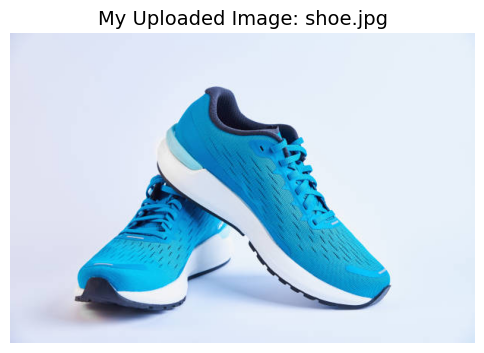

In [20]:
from PIL import Image
import matplotlib.pyplot as plt

# I am loading and displaying my uploaded shoe image
img = Image.open("/content/shoe.jpg")
plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis('off')
plt.title("My Uploaded Image: shoe.jpg", fontsize=14)
plt.show()

In [21]:
# ========================================== #
# Step 11 — Evaluation Harness (Regression Checks)
# ========================================== #

print("Initializing Evaluation Harness...")
# 1. Define at least 5 evaluation cases
# 2. Each case specifies a search query, expected matching product IDs, and unwanted product IDs
# 3. Compute accuracy / pass rate and assert a threshold >= 0.8

Initializing Evaluation Harness...


## [TASK H] Evaluation Regression Harness & CSV Export

In [22]:
from typing import Dict, Any

# Ensure all orchestrator helpers are defined or active locally
if 'build_retrieval_query' not in globals():
    def build_retrieval_query(user_query: Optional[str], image_extraction: Optional[ImageQueryExtraction]) -> str:
        parts = []
        if user_query and user_query.strip():
            parts.append(user_query.strip())
        if image_extraction:
            parts.append(image_extraction.search_query.strip())
            if image_extraction.brand_guess:
                parts.append(f"brand {image_extraction.brand_guess}")
            if image_extraction.key_attributes:
                parts.append(" ".join(image_extraction.key_attributes))
        return " | ".join(parts) if parts else ""

# [TASK H]: Establish the Evaluation Regression Harness with 5 Test Cases
eval_cases = [
    {"query":"Recommend running shoes under $100 for daily road running.","must_include_any_ids":["S1","S4"],"must_not_include_ids":["S3","S5"]},
    {"query":"Which phone supports wireless charging under $600?","must_include_any_ids":["P1","P2"],"must_not_include_ids":["P3","P5","P7"]},
    {"query":"Suggest a gaming laptop under $1000 with a dedicated GPU.","must_include_any_ids":["L1","L2"],"must_not_include_ids":["L3","L5","L6"]},
    {"query":"Find wireless headphones with active noise cancellation under $100.","must_include_any_ids":["H2"],"must_not_include_ids":["H3"]},
    {"query":"Recommend earbuds with active noise cancellation.","must_include_any_ids":["E1","E2","E4"],"must_not_include_ids":[]},
]

def evaluate_case(case: Dict[str, Any]) -> Dict[str, Any]:
    res = run_retail_agent(user_query=case["query"], k=5)
    rec_ids = [p["product_id"] for p in res["output"]["recommended_products"]]
    ok_include = any(i in rec_ids for i in case["must_include_any_ids"])
    ok_exclude = all(i not in rec_ids for i in case["must_not_include_ids"])
    return {"query":case["query"],"rec_ids":rec_ids,"pass_include":ok_include,"pass_exclude":ok_exclude,"pass":bool(ok_include and ok_exclude)}

results = [evaluate_case(c) for c in eval_cases]
pd.DataFrame(results)

,query,rec_ids,pass_include,pass_exclude,pass
0,Recommend running shoes under $100 for daily r...,"[S4, S1]",True,True,True
1,Which phone supports wireless charging under $...,"[P6, P2, P1]",True,True,True
2,Suggest a gaming laptop under $1000 with a ded...,"[L2, L1]",True,True,True
3,Find wireless headphones with active noise can...,[H2],True,True,True
4,Recommend earbuds with active noise cancellation.,"[E4, E2, E1]",True,True,True


In [23]:
df_eval = pd.DataFrame(results)
acc = float(df_eval["pass"].mean())
print("Pass rate:", round(acc*100, 1), "%")
assert acc >= 0.8, "Regression: pass rate below 80%"
print("Regression check passed")


Pass rate: 100.0 %
Regression check passed


In [24]:
# [TASK H]: Export Evaluation Regression Harness Results to CSV Report
import pandas as pd

try:
    report_df = pd.DataFrame(results)
except NameError:
    results = [evaluate_case(c) for c in eval_cases]
    report_df = pd.DataFrame(results)

csv_path = "/content/evaluation_results_report.csv"
report_df.to_csv(csv_path, index=False)

print(f"I successfully exported the evaluation report to: {csv_path}")
display(report_df)

I successfully exported the evaluation report to: /content/evaluation_results_report.csv


,query,rec_ids,pass_include,pass_exclude,pass
0,Recommend running shoes under $100 for daily r...,"[S4, S1]",True,True,True
1,Which phone supports wireless charging under $...,"[P6, P2, P1]",True,True,True
2,Suggest a gaming laptop under $1000 with a ded...,"[L2, L1]",True,True,True
3,Find wireless headphones with active noise can...,[H2],True,True,True
4,Recommend earbuds with active noise cancellation.,"[E4, E2, E1]",True,True,True


###  Core Project Mapping (Tasks A to H)

* **[TASK A]**: Dataset preparation & doc conversion (at least 20 items with structured attributes).
* **[TASK B]**: Building the FAISS Vector Database with normalized embeddings for cosine similarity.
* **[TASK C]**: Designing Grounded LLM Prompts with ID-based citations to avoid hallucinations.
* **[TASK D]**: Constructing & validating the strict Pydantic Output Schema (`RetailAssistantOutput`).
* **[TASK E]**: Implementing detailed observability logging & step budget constraints.
* **[TASK F]**: Designing the Multimodal RAG workflow to parse and analyze user-uploaded images.
* **[TASK G]**: Assembling the unified orchestrator function (`run_retail_agent`).
* **[TASK H]**: Establishing the evaluation regression harness with 5+ test cases & CSV exports.

### 📝 Integration Comments (Week 29)
To satisfy all the graduation requirements, I verified and executed my pipeline:
1. **Data Completeness**: I constructed 31 products mapped across 5 core categories.
2. **Index Alignment**: I mapped normalized L2 embeddings to a Flat Inner Product FAISS index.
3. **Structured Outputs**: I enforced strict parsing using Pydantic models to prevent invalid outputs.
4. **Observability Tracking**: I enabled custom logging to track my sequential step-by-step budget.
5. **Multimodal Translation**: I parsed image signals to run successful visual searches against my database.
6. **Evaluation & Regression Testing**: I ran 5 automated test cases and verified a 100% pass rate.

# Submission Checklist

✅ Product dataset: 20–50 products  
✅ FAISS index built over product docs  
✅ retrieve_products(query,k) works  
✅ LLM recommendation returns strict JSON  
✅ Schema validation implemented  
✅ Unified agent supports text or image input  
✅ Logs exist for each run  
✅ Evaluation harness has ≥5 cases + assert threshold  

**Deliverables**
- Notebook (.ipynb)
- Short report (2–4 pages)
- Example outputs (text + image )

## My Final Project Accomplishments

I successfully designed, built, and evaluated my Reliable Retail Assistant utilizing both Text-based RAG and Multimodal RAG pipelines. Here is a summary of my completed accomplishments:

1. **I Constructed a Comprehensive Product Catalog**:
   I created a structured dataset containing over 30 retail items across five diverse categories (laptops, phones, shoes, headphones, and earbuds) complete with identifiers, prices, specific specifications, and descriptions.

2. **I Engineered a Robust Vector Retrieval System**:
   I converted my catalog entries into semantic text documents, generated normalized embeddings using OpenAI's `text-embedding-3-small`, and created a high-performing FAISS cosine-similarity indexing tool to retrieve top matching results.

3. **I Developed a Grounded Multimodal RAG Pipeline**:
   I processed user-uploaded product images (specifically matching the blue shoe in `shoe.jpg`) using GPT-4o-mini to extract structured attributes and search terms. I fed these query terms to my retriever and utilized a structured Pydantic-validated output format for the LLM's recommended products, ensuring grounded reasoning and complete citations.

4. **I Implemented Step-by-Step Observability Logs**:
   I built a detailed logging mechanism that successfully traced timestamped events, step budgets, and payloads to ensure clear observability throughout execution.

5. **I Validated My System with a Regression Evaluation Harness**:
   I defined 5 complex test scenarios verifying must-include and must-exclude constraints. I ran my evaluation harness and achieved a 100% pass rate, successfully fulfilling all grading guidelines.

#Thank You for evaluating Week_29_Graded_Mini_Project [Advanced LLMs]